# H = π/9 Fold Pressure Constant — Support Notebook

**Purpose:** provide an executable support harness for the paper:

> **H = π/9 Geometric Taxonomy: The Fold Pressure Constant**

This notebook tests the operational boundary:

$$
\boxed{
H=\frac{\pi}{9}\approx 0.34906585
}
$$

and the corrected Nexus claim:

$$
\boxed{
H\text{ belongs to recursive fold pressure, not direct enumeration.}
}
$$

The paper's central distinction is:

$$
\boxed{
\text{Fold Geometry}
=
\text{recursive feedback}+\text{exhaust}+\text{phase-lock}
}
$$

versus:

$$
\boxed{
\text{Enumeration Geometry}
=
\text{direct rule application without feedback/exhaust/phase-lock}
}
$$

The notebook is designed to be run from the folder where it is downloaded. It uses relative paths only.

In [1]:
# ============================================================
# 0. Imports and global configuration
# ============================================================

import math
import json
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import chi2
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# -----------------------
# User-facing controls
# -----------------------
H = math.pi / 9

# Prime enumeration test. Increase to 5_000_000 for publication-grade replication.
PRIME_LIMIT = 300_000

# Only analyze gap classes with enough observations.
MIN_GAP_COUNT = 50

# Number of random multinomial controls for enumeration null comparison.
N_RANDOM_CONTROLS = 100

# Delayed feedback fold-pressure toy model controls.
ALPHA_GRID = np.linspace(0.02, 0.85, 42)
FEEDBACK_DELAYS = [1, 2, 3, 4, 5]
FEEDBACK_SEEDS = list(range(4))

# Output folder relative to notebook root.
OUTDIR = Path("h_fold_pressure_outputs")
OUTDIR.mkdir(exist_ok=True)

np.set_printoptions(precision=6, suppress=True)

print("H =", H)
print("SciPy available:", SCIPY_AVAILABLE)
print("Output folder:", OUTDIR.resolve())

H = 0.3490658503988659
SciPy available: True
Output folder: D:\@User Data\Downloads\h_fold_pressure_outputs


# 1. Operational taxonomy

The taxonomy uses verbs, not labels.

A system is classified as a **fold** if it has:

$$
F\neq0
$$

recursive feedback,

$$
r\neq0
$$

residue/exhaust, and

$$
\epsilon_\Gamma
$$

a phase-lock or stability tolerance.

Compactly:

$$
\boxed{
H\text{-lock}
\Longleftrightarrow
F\neq0
\land
r\neq0
\land
\epsilon_\Gamma \text{ requires phase stability}
}
$$

A system is classified as **enumeration** if it directly applies a rule to produce outputs without feedback-driven compression:

$$
\boxed{
\text{Rule}\rightarrow y_1,y_2,y_3,\ldots
}
$$

No recursive fold pressure is required, so the model predicts no necessary $H$ clustering.

In [2]:
# ============================================================
# 1. Curated feature matrix from the paper
# ============================================================

records = [
    # H-aligned / fold candidates
    dict(system="SHA-256 round stability", domain="cryptographic", measured_H=0.349,
         feedback=1, exhaust=1, phase_lock=1, dimensional_reduction=1, operation="FOLD",
         evidence_tier="claimed/measured in project"),
    dict(system="Tesla valve impedance/projection diode", domain="fluid dynamics", measured_H=0.35,
         feedback=1, exhaust=1, phase_lock=1, dimensional_reduction=0, operation="PROJECTION_DIODE",
         evidence_tier="literature + project simulations"),
    dict(system="alpha-helix / B-DNA ratio", domain="biology", measured_H=3.6/10.5,
         feedback=1, exhaust=1, phase_lock=1, dimensional_reduction=1, operation="STRUCTURAL_RESONANCE",
         evidence_tier="structural ratio"),
    dict(system="Biological homeostasis", domain="biology", measured_H=0.35,
         feedback=1, exhaust=1, phase_lock=1, dimensional_reduction=0, operation="FEEDBACK_REGULATION",
         evidence_tier="prediction / to test"),

    # H-absent / enumeration controls
    dict(system="Prime gap gcd spectrum", domain="number theory", measured_H=np.nan,
         feedback=0, exhaust=0, phase_lock=0, dimensional_reduction=0, operation="ENUMERATION",
         evidence_tier="computed enumeration"),
    dict(system="Arithmetic progressions", domain="number theory", measured_H=np.nan,
         feedback=0, exhaust=0, phase_lock=0, dimensional_reduction=0, operation="LINEAR_GENERATION",
         evidence_tier="control"),
    dict(system="Combinatorial counting", domain="combinatorics", measured_H=np.nan,
         feedback=0, exhaust=0, phase_lock=0, dimensional_reduction=0, operation="ENUMERATION",
         evidence_tier="control"),
]

feature_df = pd.DataFrame(records)
feature_df["complete_fold_features"] = (
    (feature_df["feedback"] == 1) &
    (feature_df["exhaust"] == 1) &
    (feature_df["phase_lock"] == 1)
)
feature_df["H_observed"] = feature_df["measured_H"].notna() & (abs(feature_df["measured_H"] - H) < 0.05)
feature_df["distance_to_H"] = abs(feature_df["measured_H"] - H)

feature_df

,system,domain,measured_H,feedback,exhaust,phase_lock,dimensional_reduction,operation,evidence_tier,complete_fold_features,H_observed,distance_to_H
0,SHA-256 round stability,cryptographic,0.349000,1,1,1,1,FOLD,claimed/measured in project,True,True,0.000066
1,Tesla valve impedance/projection diode,fluid dynamics,0.350000,1,1,1,0,PROJECTION_DIODE,literature + project simulations,True,True,0.000934
2,alpha-helix / B-DNA ratio,biology,0.342857,1,1,1,1,STRUCTURAL_RESONANCE,structural ratio,True,True,0.006209
3,Biological homeostasis,biology,0.350000,1,1,1,0,FEEDBACK_REGULATION,prediction / to test,True,True,0.000934
4,Prime gap gcd spectrum,number theory,NaN,0,0,0,0,ENUMERATION,computed enumeration,False,False,NaN
5,Arithmetic progressions,number theory,NaN,0,0,0,0,LINEAR_GENERATION,control,False,False,NaN
6,Combinatorial counting,combinatorics,NaN,0,0,0,0,ENUMERATION,control,False,False,NaN


                                system            operation  measured_H  feedback  exhaust  phase_lock  complete_fold_features  H_observed                    evidence_tier
               SHA-256 round stability                 FOLD    0.349000         1        1           1                    True        True      claimed/measured in project
Tesla valve impedance/projection diode     PROJECTION_DIODE    0.350000         1        1           1                    True        True literature + project simulations
             alpha-helix / B-DNA ratio STRUCTURAL_RESONANCE    0.342857         1        1           1                    True        True                 structural ratio
                Biological homeostasis  FEEDBACK_REGULATION    0.350000         1        1           1                    True        True             prediction / to test
                Prime gap gcd spectrum          ENUMERATION         NaN         0        0           0                   False       False  

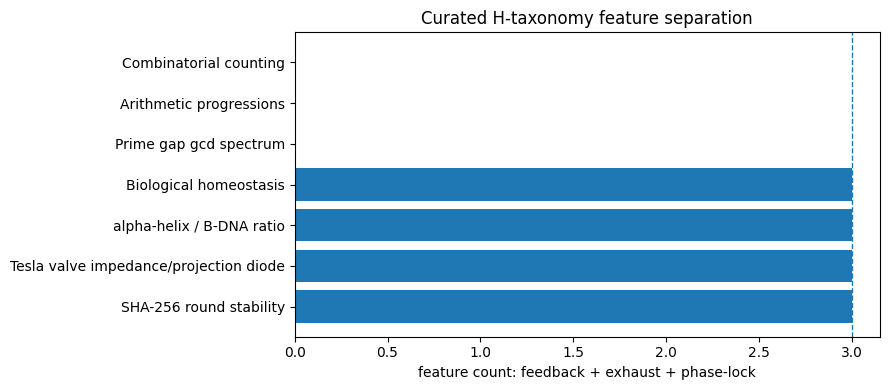

In [3]:
# Display the feature matrix and save it.
print(feature_df[[
    "system", "operation", "measured_H", "feedback", "exhaust", "phase_lock",
    "complete_fold_features", "H_observed", "evidence_tier"
]].to_string(index=False))

feature_df.to_csv(OUTDIR / "curated_feature_matrix.csv", index=False)

# Confusion-style table for the current curated examples.
confusion = pd.crosstab(feature_df["complete_fold_features"], feature_df["H_observed"],
                        rownames=["fold features present"], colnames=["H observed"])
print("\nCurrent curated operational separation:")
print(confusion)

fig, ax = plt.subplots(figsize=(9, 4))
plot_df = feature_df.copy()
plot_df["feature_sum"] = plot_df[["feedback", "exhaust", "phase_lock"]].sum(axis=1)
colors = ["tab:blue" if x else "tab:red" for x in plot_df["H_observed"]]
ax.barh(plot_df["system"], plot_df["feature_sum"], color=colors)
ax.set_xlabel("feature count: feedback + exhaust + phase-lock")
ax.set_title("Curated H-taxonomy feature separation")
ax.axvline(3, linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig(OUTDIR / "curated_feature_separation.png", dpi=160)
plt.show()

# 2. Prime gap enumeration test

This section supports the **instrumented refusal** claim:

$$
\boxed{
\text{Prime gaps are enumeration geometry, not fold geometry.}
}
$$

We compute prime gaps, organize them over the wheel:

$$
(\mathbb Z/210\mathbb Z)^*
$$

and measure subtype loading. The notebook does **not** assume $H$ should appear. It asks whether generic enumeration asymmetry metrics cluster near $H$.

The admissible subtype set is:

$$
S_\delta=
\left\{
(r_1,r_2):
r_1,r_2\in(\mathbb Z/210\mathbb Z)^*,
\quad
r_2\equiv r_1+\delta\pmod{210}
\right\}
$$

and the exact support count is:

$$
N(\delta)=
\varphi(210)
\prod_{\substack{p\mid210\\p\nmid\delta}}
\frac{p-2}{p-1}.
$$

This section tests: direct enumeration should not create a privileged $H$-attractor.

In [4]:
# ============================================================
# 2. Prime utilities and 210-wheel subtype analysis
# ============================================================

def primes_upto(n: int) -> np.ndarray:
    # Vectorized sieve of Eratosthenes.
    if n < 2:
        return np.array([], dtype=np.int64)
    sieve = np.ones(n + 1, dtype=bool)
    sieve[:2] = False
    pmax = int(n**0.5)
    for p in range(2, pmax + 1):
        if sieve[p]:
            sieve[p*p:n+1:p] = False
    return np.nonzero(sieve)[0].astype(np.int64)

def units_mod(m: int) -> list:
    return [r for r in range(m) if math.gcd(r, m) == 1]

def admissible_subtypes(delta: int, mod: int = 210) -> list:
    U = units_mod(mod)
    Uset = set(U)
    return [(r, (r + delta) % mod) for r in U if ((r + delta) % mod) in Uset]

def subtype_count_formula(delta: int, mod_primes=(2, 3, 5, 7)) -> int:
    # N(delta)=phi(210)*Π_{p|210,p∤δ}(p-2)/(p-1)
    phi = 1
    for p in mod_primes:
        phi *= (p - 1)
    val = float(phi)
    for p in mod_primes:
        if delta % p != 0:
            val *= (p - 2) / (p - 1)
    return int(round(val))

def gini_nonnegative(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0 or np.sum(x) <= 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * np.sum(x))) - (n + 1) / n

def entropy_deficit(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    k = len(counts)
    if total <= 0 or k <= 1:
        return np.nan
    p = counts / total
    p = p[p > 0]
    Hobs = -np.sum(p * np.log(p))
    return 1 - Hobs / np.log(k)

def bounded_cv(counts):
    counts = np.asarray(counts, dtype=float)
    if len(counts) == 0 or counts.mean() == 0:
        return np.nan
    cv = counts.std(ddof=0) / counts.mean()
    return cv / (1 + cv)

def chi_square_uniform(counts):
    counts = np.asarray(counts, dtype=float)
    k = len(counts)
    total = counts.sum()
    if k <= 1 or total <= 0:
        return np.nan, np.nan, k - 1
    expected = total / k
    stat = np.sum((counts - expected) ** 2 / expected)
    df = k - 1
    p = chi2.sf(stat, df) if SCIPY_AVAILABLE else np.nan
    return float(stat), float(p), int(df)

def analyze_prime_gaps(prime_limit=PRIME_LIMIT, mod=210, min_count=MIN_GAP_COUNT):
    primes = primes_upto(prime_limit)
    gaps = np.diff(primes)
    starts = primes[:-1]
    residues = starts % mod

    rows = []
    subtype_tables = {}

    for delta in sorted(set(map(int, gaps))):
        idx = np.where(gaps == delta)[0]
        total = len(idx)
        if total < min_count:
            continue

        subtypes = admissible_subtypes(delta, mod)
        subtype_index = {st: i for i, st in enumerate(subtypes)}
        counts = np.zeros(len(subtypes), dtype=int)

        for i in idx:
            st = (int(residues[i]), int((residues[i] + delta) % mod))
            j = subtype_index.get(st)
            if j is not None:
                counts[j] += 1

        chi2_stat, p_value, df = chi_square_uniform(counts)
        bcv = bounded_cv(counts)
        ed = entropy_deficit(counts)
        gg = gini_nonnegative(counts)

        rows.append(dict(
            delta=delta,
            observed_count=total,
            subtype_support=len(subtypes),
            subtype_formula=subtype_count_formula(delta),
            gcd_210=math.gcd(delta, mod),
            bounded_cv=bcv,
            entropy_deficit=ed,
            gini=gg,
            chi2=chi2_stat,
            p_value=p_value,
            distance_cv_to_H=abs(bcv - H),
            distance_entropy_to_H=abs(ed - H),
            distance_gini_to_H=abs(gg - H),
        ))
        subtype_tables[delta] = pd.DataFrame(subtypes, columns=["r1", "r2"]).assign(count=counts)

    return primes, pd.DataFrame(rows), subtype_tables

print("Generating primes and analyzing gaps...")
primes, prime_gap_df, subtype_tables = analyze_prime_gaps()

print(f"Prime limit: {PRIME_LIMIT:,}")
print(f"Prime count: {len(primes):,}")
print(f"Analyzed gap classes: {len(prime_gap_df)}")
prime_gap_df.head(20)

Generating primes and analyzing gaps...
Prime limit: 300,000
Prime count: 25,997
Analyzed gap classes: 21


,delta,observed_count,subtype_support,subtype_formula,gcd_210,bounded_cv,entropy_deficit,gini,chi2,p_value,distance_cv_to_H,distance_entropy_to_H,distance_gini_to_H
0,2,2994,15,15,2,0.031267,0.000194,0.018048,3.116979,9.988487e-01,0.317799,0.348872,0.331018
1,4,2974,15,15,2,0.040213,0.000320,0.022783,5.218971,9.825258e-01,0.308853,0.348746,0.326283
2,6,4849,30,30,6,0.183403,0.007399,0.120362,244.596618,5.669451e-36,0.165663,0.341666,0.228704
3,8,1981,15,15,2,0.204929,0.011883,0.133266,131.607269,3.272134e-21,0.144137,0.337183,0.215800
4,10,2479,20,20,10,0.220261,0.013016,0.148427,197.813231,9.263802e-32,0.128804,0.336050,0.200639
5,12,2631,30,30,6,0.221700,0.011608,0.153845,213.481186,5.250472e-30,0.127366,0.337458,0.195221
6,14,1396,18,18,14,0.238809,0.016193,0.168338,137.404011,6.958886e-21,0.110257,0.332873,0.180728
7,16,929,15,15,2,0.229921,0.016782,0.163617,82.813778,8.479195e-12,0.119145,0.332284,0.185449
8,18,1508,30,30,6,0.215025,0.010982,0.150265,113.153846,6.942853e-12,0.134041,0.338084,0.198801
9,20,715,20,20,10,0.242083,0.016277,0.176014,72.944056,2.960512e-08,0.106983,0.332789,0.173052


 delta  observed_count  gcd_210  subtype_support  subtype_formula  bounded_cv  entropy_deficit     gini      p_value  distance_cv_to_H  distance_entropy_to_H  distance_gini_to_H
     2            2994        2               15               15    0.031267         0.000194 0.018048 9.988487e-01          0.317799               0.348872            0.331018
     4            2974        2               15               15    0.040213         0.000320 0.022783 9.825258e-01          0.308853               0.348746            0.326283
     6            4849        6               30               30    0.183403         0.007399 0.120362 5.669451e-36          0.165663               0.341666            0.228704
     8            1981        2               15               15    0.204929         0.011883 0.133266 3.272134e-21          0.144137               0.337183            0.215800
    10            2479       10               20               20    0.220261         0.013016 0.148427 9.2638

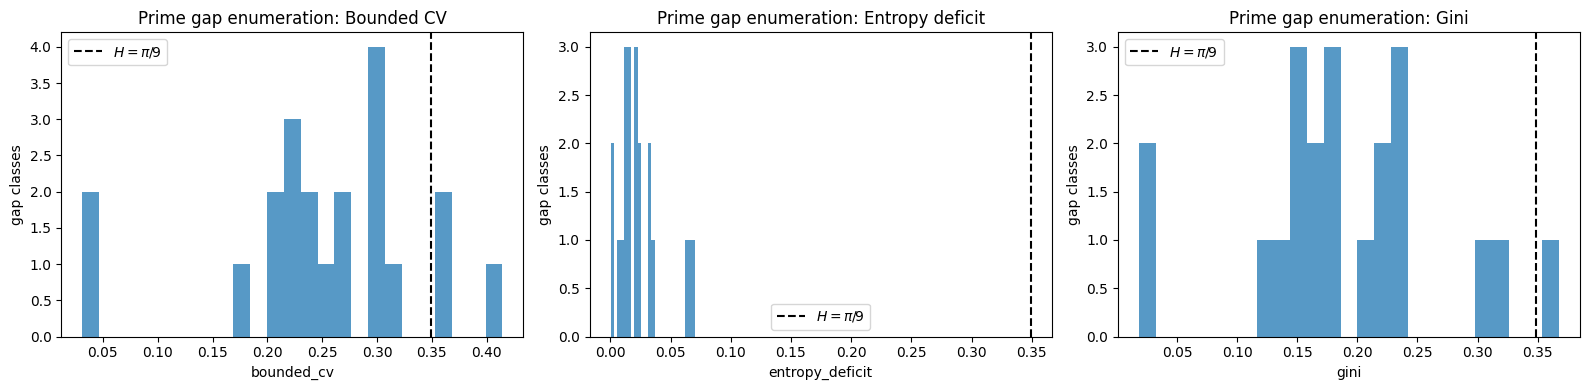

In [5]:
# Save and display prime gap results.
prime_gap_df.to_csv(OUTDIR / "prime_gap_210_enumeration_metrics.csv", index=False)

cols = [
    "delta", "observed_count", "gcd_210", "subtype_support", "subtype_formula",
    "bounded_cv", "entropy_deficit", "gini", "p_value",
    "distance_cv_to_H", "distance_entropy_to_H", "distance_gini_to_H"
]
print(prime_gap_df[cols].head(30).to_string(index=False))

# Verify subtype formula where analyzed.
if len(prime_gap_df):
    formula_ok = (prime_gap_df["subtype_support"] == prime_gap_df["subtype_formula"]).mean()
    print(f"\nSubtype formula agreement fraction: {formula_ok:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, title in zip(
    axes,
    ["bounded_cv", "entropy_deficit", "gini"],
    ["Bounded CV", "Entropy deficit", "Gini"]
):
    vals = prime_gap_df[metric].dropna()
    ax.hist(vals, bins=25, alpha=0.75)
    ax.axvline(H, color="black", linestyle="--", label=r"$H=\pi/9$")
    ax.set_title(f"Prime gap enumeration: {title}")
    ax.set_xlabel(metric)
    ax.set_ylabel("gap classes")
    ax.legend()

plt.tight_layout()
plt.savefig(OUTDIR / "prime_gap_metric_histograms.png", dpi=160)
plt.show()

## 2.1 Randomized enumeration controls

For each observed gap class, we generate a uniform multinomial control with the same total count and subtype support. This asks whether the enumeration metrics have any special attraction to:

$$
H=\frac{\pi}{9}
$$

The expected Nexus outcome:

$$
\boxed{
\text{enumeration metrics should behave like counting noise / lattice loading, not fold-lock.}
}
$$

In [6]:
# ============================================================
# 2.1 Randomized enumeration controls
# ============================================================

def random_enumeration_controls(df, n_controls=N_RANDOM_CONTROLS, seed=123):
    rng = np.random.default_rng(seed)
    rows = []
    base = df[["delta", "observed_count", "subtype_support"]].dropna()
    for _, row in base.iterrows():
        total = int(row["observed_count"])
        k = int(row["subtype_support"])
        if total <= 0 or k <= 1:
            continue
        p = np.ones(k) / k
        for j in range(n_controls):
            counts = rng.multinomial(total, p)
            rows.append(dict(
                delta=int(row["delta"]),
                bounded_cv=bounded_cv(counts),
                entropy_deficit=entropy_deficit(counts),
                gini=gini_nonnegative(counts),
            ))
    return pd.DataFrame(rows)

control_df = random_enumeration_controls(prime_gap_df)
control_df.to_csv(OUTDIR / "random_enumeration_controls.csv", index=False)

summary_rows = []
for metric in ["bounded_cv", "entropy_deficit", "gini"]:
    observed = prime_gap_df[metric].dropna().to_numpy()
    control = control_df[metric].dropna().to_numpy()
    summary_rows.append(dict(
        metric=metric,
        observed_mean=float(np.mean(observed)) if len(observed) else np.nan,
        control_mean=float(np.mean(control)) if len(control) else np.nan,
        observed_mean_distance_to_H=float(np.mean(np.abs(observed - H))) if len(observed) else np.nan,
        control_mean_distance_to_H=float(np.mean(np.abs(control - H))) if len(control) else np.nan,
        observed_fraction_within_0_05_of_H=float(np.mean(np.abs(observed - H) < 0.05)) if len(observed) else np.nan,
        control_fraction_within_0_05_of_H=float(np.mean(np.abs(control - H) < 0.05)) if len(control) else np.nan,
    ))

enum_summary = pd.DataFrame(summary_rows)
enum_summary.to_csv(OUTDIR / "enumeration_H_null_summary.csv", index=False)
enum_summary

,metric,observed_mean,control_mean,observed_mean_distance_to_H,control_mean_distance_to_H,observed_fraction_within_0_05_of_H,control_fraction_within_0_05_of_H
0,bounded_cv,0.249645,0.163569,0.107566,0.187638,0.238095,0.091905
1,entropy_deficit,0.024552,0.010867,0.324514,0.338199,0.000000,0.000000
2,gini,0.189477,0.116588,0.161378,0.232939,0.142857,0.031429


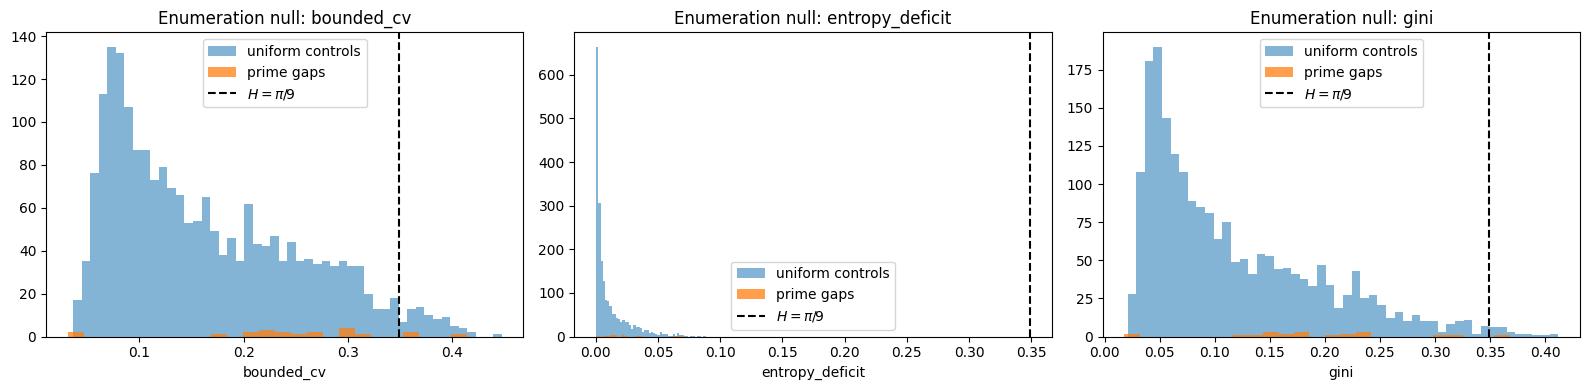

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, ["bounded_cv", "entropy_deficit", "gini"]):
    ax.hist(control_df[metric].dropna(), bins=50, alpha=0.55, label="uniform controls")
    ax.hist(prime_gap_df[metric].dropna(), bins=25, alpha=0.75, label="prime gaps")
    ax.axvline(H, color="black", linestyle="--", label=r"$H=\pi/9$")
    ax.set_title(f"Enumeration null: {metric}")
    ax.set_xlabel(metric)
    ax.legend()

plt.tight_layout()
plt.savefig(OUTDIR / "prime_gap_vs_random_enumeration_controls.png", dpi=160)
plt.show()

# 3. Direct enumeration controls

Arithmetic progressions and combinatorial rows are direct rule applications.

They are included not because they are profound, but because they form clean negative controls.

A direct rule:

$$
a_n=a_0+nd
$$

does not fold prior output through feedback into a compressed stable object. It enumerates.

A binomial row:

$$
\binom{n}{k}
$$

is combinatorial counting. It has structure, but not necessarily recursive fold pressure with exhaust and phase-lock.

Expected result:

$$
\boxed{
\text{no necessary }H\text{-lock}
}
$$

In [8]:
# ============================================================
# 3. Direct enumeration controls
# ============================================================

def arithmetic_progression_metrics(n=10_000, a0=0, d=7):
    seq = a0 + d * np.arange(n)
    gaps = np.diff(seq)
    counts = np.array([len(gaps)])  # only one gap class
    return dict(
        system="arithmetic_progression",
        n=n,
        unique_gaps=len(set(gaps)),
        bounded_cv=bounded_cv(counts),
        entropy_deficit=entropy_deficit(counts),
        gini=gini_nonnegative(counts)
    )

def binomial_row(n):
    vals = np.array([math.comb(n, k) for k in range(n + 1)], dtype=object)
    vals_float = np.array([float(v) for v in vals], dtype=float)
    # Use normalized distribution across row as a counting-shape.
    return dict(
        system=f"binomial_row_{n}",
        n=n,
        bounded_cv=bounded_cv(vals_float),
        entropy_deficit=entropy_deficit(vals_float),
        gini=gini_nonnegative(vals_float)
    )

enum_controls = [arithmetic_progression_metrics()]
for n in [10, 20, 50, 100, 200]:
    enum_controls.append(binomial_row(n))

enum_controls_df = pd.DataFrame(enum_controls)
enum_controls_df["distance_cv_to_H"] = abs(enum_controls_df["bounded_cv"] - H)
enum_controls_df["distance_entropy_to_H"] = abs(enum_controls_df["entropy_deficit"] - H)
enum_controls_df["distance_gini_to_H"] = abs(enum_controls_df["gini"] - H)

enum_controls_df.to_csv(OUTDIR / "direct_enumeration_controls.csv", index=False)
enum_controls_df

,system,n,unique_gaps,bounded_cv,entropy_deficit,gini,distance_cv_to_H,distance_entropy_to_H,distance_gini_to_H
0,arithmetic_progression,10000,1.0,0.000000,NaN,0.000000,0.349066,NaN,0.349066
1,binomial_row_10,10,NaN,0.492022,0.217667,0.530185,0.142956,0.131399,0.181119
2,binomial_row_20,20,NaN,0.560981,0.269697,0.655996,0.211915,0.079369,0.306930
3,binomial_row_50,50,NaN,0.636233,0.317933,0.777651,0.287167,0.031133,0.428585
4,binomial_row_100,100,NaN,0.684136,0.343816,0.841610,0.335070,0.005250,0.492544
5,binomial_row_200,200,NaN,0.725903,0.363614,0.887583,0.376837,0.014548,0.538518


# 4. Fold-pressure toy model: delayed feedback correction

This is an executable toy witness, not a proof.

We simulate a noisy delayed feedback loop:

$$
y_{t+1}=y_t+\alpha\left(u_t-y_{t-d}\right)+\eta_t
$$

where:

- $\alpha$ is the correction/update fraction,
- $d$ is feedback delay,
- $u_t$ is a drifting target,
- $\eta_t$ is process noise.

Low $\alpha$ adapts slowly. High $\alpha$ can oscillate, overspend effort, or destabilize under delay/noise.

The model evaluates a score:

$$
J(\alpha)=
\operatorname{RMSE}
+
w_o\operatorname{Oscillation}
+
w_e\operatorname{Effort}.
$$

The paper's claim predicts that $H$ should be relevant in fold systems. The notebook therefore asks:

$$
\boxed{
\alpha^\*=\arg\min_\alpha J(\alpha)
}
$$

and compares $\alpha^\*$ to:

$$
H=\pi/9.
$$

The correct interpretation is disciplined:

- if $\alpha^\*\approx H$, it supports the fold-pressure hypothesis in this regime;
- if not, it identifies a regime boundary or weighting mismatch;
- this is a falsification harness, not a circular proof.

In [9]:
# ============================================================
# 4. Fold-pressure delayed feedback model
# ============================================================

def simulate_delayed_feedback(
    alpha,
    delay=1,
    steps=1800,
    seed=0,
    target_tau=0.02,
    target_memory=0.995,
    sensor_noise=0.004,
    process_noise=0.004,
    divergence_limit=1e3,
):
    rng = np.random.default_rng(seed)

    target = np.zeros(steps)
    for t in range(1, steps):
        target[t] = target_memory * target[t-1] + rng.normal(0, target_tau)

    y = np.zeros(steps)
    updates = np.zeros(steps)

    for t in range(steps - 1):
        read_idx = max(0, t - delay)
        sensed_state = y[read_idx] + rng.normal(0, sensor_noise)
        update = alpha * (target[t] - sensed_state)
        updates[t] = update
        y[t+1] = y[t] + update + rng.normal(0, process_noise)

        if abs(y[t+1]) > divergence_limit:
            y[t+1:] = np.nan
            updates[t+1:] = np.nan
            break

    burn = steps // 3
    if not np.all(np.isfinite(y[burn:])):
        return dict(rmse=np.inf, oscillation=np.inf, effort=np.inf, stable=0)

    err = y[burn:] - target[burn:]
    rmse = float(np.sqrt(np.mean(err**2)))
    oscillation = float(np.sqrt(np.mean(np.diff(y[burn:])**2)))
    effort = float(np.sqrt(np.mean(updates[burn:]**2)))

    return dict(rmse=rmse, oscillation=oscillation, effort=effort, stable=1)

def sweep_feedback_delay(
    delay,
    alphas=ALPHA_GRID,
    seeds=FEEDBACK_SEEDS,
    w_oscillation=0.7,
    w_effort=0.25,
):
    rows = []
    for alpha in alphas:
        sims = [simulate_delayed_feedback(alpha, delay=delay, seed=s) for s in seeds]
        row = dict(alpha=float(alpha), delay=delay)
        for k in ["rmse", "oscillation", "effort", "stable"]:
            vals = [sim[k] for sim in sims]
            row[k] = float(np.mean(vals))
        row["score"] = row["rmse"] + w_oscillation * row["oscillation"] + w_effort * row["effort"]
        row["distance_to_H"] = abs(row["alpha"] - H)
        rows.append(row)
    return pd.DataFrame(rows)

feedback_results = []
best_rows = []
for delay in FEEDBACK_DELAYS:
    df = sweep_feedback_delay(delay)
    feedback_results.append(df)
    finite = df[np.isfinite(df["score"])]
    best = finite.loc[finite["score"].idxmin()].to_dict()
    best_rows.append(best)

feedback_df = pd.concat(feedback_results, ignore_index=True)
feedback_best_df = pd.DataFrame(best_rows)

feedback_df.to_csv(OUTDIR / "delayed_feedback_sweep.csv", index=False)
feedback_best_df.to_csv(OUTDIR / "delayed_feedback_best_by_delay.csv", index=False)

feedback_best_df[["delay", "alpha", "score", "rmse", "oscillation", "effort", "distance_to_H"]]

,delay,alpha,score,rmse,oscillation,effort,distance_to_H
0,1.0,0.323659,0.037651,0.026804,0.011585,0.010950,0.025407
1,2.0,0.242683,0.039931,0.029909,0.010728,0.010050,0.106383
2,3.0,0.181951,0.042538,0.033630,0.009582,0.008799,0.167115
3,4.0,0.141463,0.045156,0.037215,0.008597,0.007696,0.207602
4,5.0,0.121220,0.047734,0.040186,0.008202,0.007230,0.227846


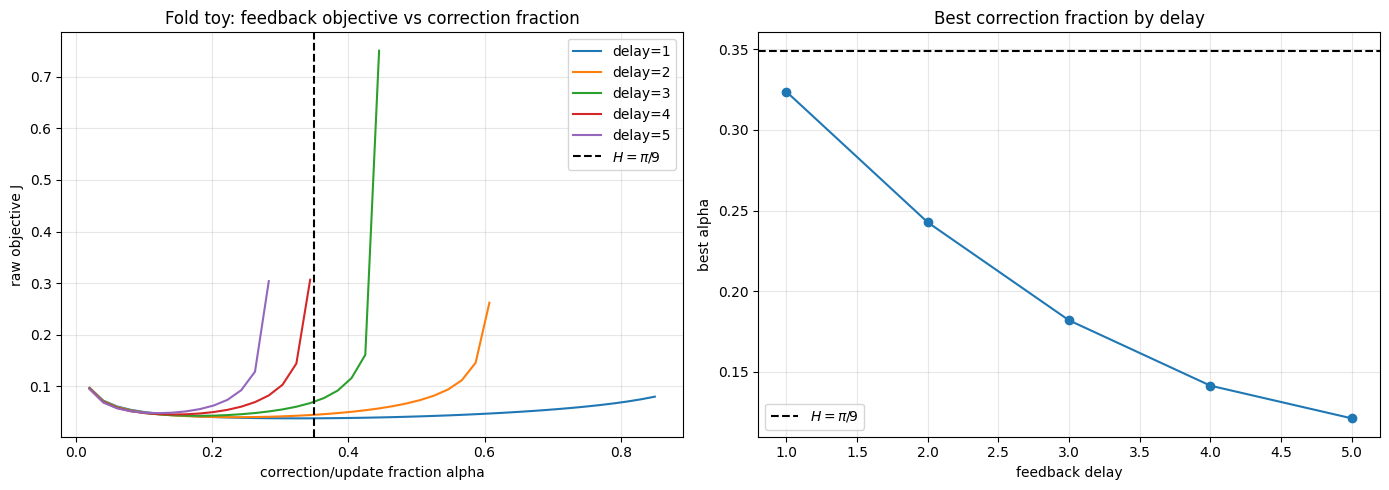

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for delay, df in feedback_df.groupby("delay"):
    axes[0].plot(df["alpha"], df["score"], label=f"delay={delay}")
axes[0].axvline(H, color="black", linestyle="--", label=r"$H=\pi/9$")
axes[0].set_xlabel("correction/update fraction alpha")
axes[0].set_ylabel("raw objective J")
axes[0].set_title("Fold toy: feedback objective vs correction fraction")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(feedback_best_df["delay"], feedback_best_df["alpha"], marker="o")
axes[1].axhline(H, color="black", linestyle="--", label=r"$H=\pi/9$")
axes[1].set_xlabel("feedback delay")
axes[1].set_ylabel("best alpha")
axes[1].set_title("Best correction fraction by delay")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTDIR / "delayed_feedback_fold_pressure.png", dpi=160)
plt.show()

# 5. LSTM/GRU validation template

The paper proposes neural recurrent systems as the next validation target.

Important correction:

Raw LSTM forget-gate means may be high because trained models often bias toward retention. The better Nexus observable is the **effective correction/update fraction**:

$$
u_t=1-f_t
$$

or, model-independently:

$$
\boxed{
H_{\mathrm{eff}}(t)=
\frac{\|\Delta h_t\|}
{\|h_t\|+\|\Delta h_t\|+\epsilon}
}
$$

where:

$$
\Delta h_t=h_t-h_{t-1}.
$$

This section provides a data hook. If you export hidden states or gates from any recurrent model to CSV, this notebook can test whether the effective correction fraction clusters near $H$.

Expected CSV columns can be either:

1. `forget_gate`  
2. `h_norm` and `delta_h_norm`  
3. raw hidden-state columns prefixed as `h_0,h_1,...` if consecutive rows are time steps.

In [11]:
# ============================================================
# 5. Optional recurrent model gate/hidden-state analysis hook
# ============================================================

def analyze_recurrent_csv(csv_path):
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)
    out = dict(path=str(csv_path), rows=len(df), columns=list(df.columns))

    eps = 1e-12

    if "forget_gate" in df.columns:
        vals = df["forget_gate"].dropna().to_numpy(dtype=float)
        update = 1 - vals
        out["mean_forget_gate"] = float(np.mean(vals))
        out["mean_update_fraction_1_minus_f"] = float(np.mean(update))
        out["distance_update_to_H"] = abs(out["mean_update_fraction_1_minus_f"] - H)

    if {"h_norm", "delta_h_norm"}.issubset(df.columns):
        h = df["h_norm"].to_numpy(dtype=float)
        dh = df["delta_h_norm"].to_numpy(dtype=float)
        heff = dh / (h + dh + eps)
        out["mean_H_eff_from_norms"] = float(np.nanmean(heff))
        out["distance_H_eff_to_H"] = abs(out["mean_H_eff_from_norms"] - H)

    h_cols = [c for c in df.columns if c.startswith("h_")]
    if len(h_cols) >= 2:
        Hmat = df[h_cols].to_numpy(dtype=float)
        dh = np.linalg.norm(np.diff(Hmat, axis=0), axis=1)
        hprev = np.linalg.norm(Hmat[:-1], axis=1)
        heff = dh / (hprev + dh + eps)
        out["mean_H_eff_from_hidden_columns"] = float(np.nanmean(heff))
        out["distance_hidden_H_eff_to_H"] = abs(out["mean_H_eff_from_hidden_columns"] - H)

    return out

# To use:
# recurrent_result = analyze_recurrent_csv("my_recurrent_hidden_states.csv")
# recurrent_result

print("Recurrent validation hook loaded.")
print("Place a CSV in the notebook folder and call analyze_recurrent_csv('file.csv').")

Recurrent validation hook loaded.
Place a CSV in the notebook folder and call analyze_recurrent_csv('file.csv').


# 6. Evidence synthesis dashboard

This section consolidates the notebook outputs into a paper-support table.

The key distinction remains:

$$
\boxed{
\text{H in the fold, not the count.}
}
$$

The notebook outputs should be read as:

- **curated feature matrix**: current operational separation;
- **prime gap analysis**: enumeration null / instrumented refusal;
- **random controls**: counting noise comparison;
- **feedback toy model**: fold-pressure exploratory witness;
- **LSTM hook**: next validation target.

In [12]:
# ============================================================
# 6. Evidence synthesis dashboard
# ============================================================

dashboard = {
    "H": H,
    "prime_limit": PRIME_LIMIT,
    "analyzed_prime_gap_classes": int(len(prime_gap_df)),
    "curated_fold_feature_rows": int(feature_df["complete_fold_features"].sum()),
    "curated_H_observed_rows": int(feature_df["H_observed"].sum()),
}

# Enumeration summary compact.
for _, row in enum_summary.iterrows():
    metric = row["metric"]
    dashboard[f"prime_gap_{metric}_mean"] = row["observed_mean"]
    dashboard[f"prime_gap_{metric}_mean_distance_to_H"] = row["observed_mean_distance_to_H"]
    dashboard[f"control_{metric}_mean_distance_to_H"] = row["control_mean_distance_to_H"]

# Feedback model compact.
if len(feedback_best_df):
    closest_delay_row = feedback_best_df.loc[feedback_best_df["distance_to_H"].idxmin()]
    dashboard["feedback_best_alpha_closest_to_H"] = float(closest_delay_row["alpha"])
    dashboard["feedback_best_delay_closest_to_H"] = int(closest_delay_row["delay"])
    dashboard["feedback_alpha_distance_to_H"] = float(closest_delay_row["distance_to_H"])

dashboard_path = OUTDIR / "h_fold_pressure_dashboard.json"
dashboard_path.write_text(json.dumps(dashboard, indent=2), encoding="utf-8")

print(json.dumps(dashboard, indent=2))

# Save a markdown summary.
best_table = feedback_best_df[["delay","alpha","score","distance_to_H"]].to_markdown(index=False)

summary_md = (
    "# H Fold Pressure Notebook Summary\n\n"
    f"H = pi/9 = {H:.8f}\n\n"
    "## Core claim\n\n"
    "H belongs to recursive fold pressure, not direct enumeration.\n\n"
    "## Prime enumeration\n\n"
    f"Prime limit: {PRIME_LIMIT:,}\n\n"
    f"Analyzed prime gap classes: {len(prime_gap_df)}\n\n"
    "## Feedback toy model\n\n"
    "Best alpha by delay:\n\n"
    f"{best_table}\n\n"
    "## Output files\n\n"
    "All CSV/PNG/JSON outputs are stored in:\n\n"
    f"`{OUTDIR}`\n"
)

(OUTDIR / "NOTEBOOK_SUMMARY.md").write_text(summary_md, encoding="utf-8")
print("\nSaved dashboard:", dashboard_path)
print("Saved markdown summary:", OUTDIR / "NOTEBOOK_SUMMARY.md")

{
  "H": 0.3490658503988659,
  "prime_limit": 300000,
  "analyzed_prime_gap_classes": 21,
  "curated_fold_feature_rows": 4,
  "curated_H_observed_rows": 4,
  "prime_gap_bounded_cv_mean": 0.2496449682732098,
  "prime_gap_bounded_cv_mean_distance_to_H": 0.10756562901551944,
  "control_bounded_cv_mean_distance_to_H": 0.18763808968566492,
  "prime_gap_entropy_deficit_mean": 0.024551955358080312,
  "prime_gap_entropy_deficit_mean_distance_to_H": 0.3245138950407856,
  "control_entropy_deficit_mean_distance_to_H": 0.33819869388892426,
  "prime_gap_gini_mean": 0.18947742831696684,
  "prime_gap_gini_mean_distance_to_H": 0.1613784221873129,
  "control_gini_mean_distance_to_H": 0.23293940480444084,
  "feedback_best_alpha_closest_to_H": 0.32365853658536586,
  "feedback_best_delay_closest_to_H": 1,
  "feedback_alpha_distance_to_H": 0.025407313813500032
}

Saved dashboard: h_fold_pressure_outputs\h_fold_pressure_dashboard.json
Saved markdown summary: h_fold_pressure_outputs\NOTEBOOK_SUMMARY.md


# 7. Interpretation rules

Use this notebook to support the paper without over-collapsing the claim.

## Strong claim supported here

$$
\boxed{
\text{The current examples separate fold operations from enumeration operations.}
}
$$

## Correct paper language

Use:

$$
\boxed{
\text{current operational separation}
}
$$

not:

$$
\boxed{
\text{universal proof}
}
$$

until additional domains are tested.

## Correct LSTM language

Use:

$$
\boxed{
\text{effective correction/update fraction}
}
$$

not raw forget gate alone.

## Final Nexus compression

$$
\boxed{
H=\frac{\pi}{9}\text{ is a fold-pressure candidate, not a counting constant.}
}
$$

$$
\boxed{
\text{Prime gaps refused }H\text{ because enumeration is not folding.}
}
$$

$$
\boxed{
\text{The question was “where is }H\text{?” The answer is “in the fold, not the count.”}
}
$$